In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import numpy as np
import pandas as pd
import time

In [2]:
print(torch.__version__)

2.9.1+cu128


In [3]:
def SIR(t, y, beta, gamma):
  S = y[0]
  I = y[1]
  R = y[2]
  dSdt = -beta * S * I
  dIdt = beta * S * I - gamma * I
  dRdt = gamma * I
  return np.array([dSdt, dIdt, dRdt])

In [4]:
def maki_thompson(t, y, lambd, alpha):
  X = y[0]
  Y = y[1]
  Z = y[2]
  dX = -lambd * X * Y
  dY =  lambd * X * Y - alpha * Y * (1 - X)
  dZ =  alpha * Y * (1 - X)
  return np.array([dX, dY, dZ])

In [5]:
def rk4(f, y0, t, beta, gamma):
  n = len(t)
  y0 = np.array(y0)
  y = np.zeros((n, len(y0)))
  y[0] = y0

  for i in range(n-1):
    h = t[i+1] - t[i]

    k1 = np.array(f(t[i], y[i], beta, gamma))
    k2 = np.array(f(t[i] + h/2, y[i] + h*k1/2, beta, gamma))
    k3 = np.array(f(t[i] + h/2, y[i] + h*k2/2, beta, gamma))
    k4 = np.array(f(t[i] + h, y[i] + h*k3, beta, gamma))

    y[i+1] = y[i] + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

  return y

In [6]:
class sir_nn(nn.Module):
  def __init__(self, tTrain):
    super().__init__()

    self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 3))

    self.beta = nn.Parameter(torch.tensor([0.5]))
    self.gamma = nn.Parameter(torch.tensor([0.5]))
    self.tMax = max(tTrain)

  def forward(self, t):
    t_norm = t / self.tMax
    return nn.Softplus()(self.net(t_norm))

In [7]:
class MT_nn(nn.Module):
  def __init__(self, tTrain):
    super().__init__()

    self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 3))

    self.lambd = nn.Parameter(torch.tensor([0.5]))
    self.alpha = nn.Parameter(torch.tensor([0.5]))

    self.tMax = max(tTrain)


  def forward(self, t):
    t_norm = t / self.tMax
    return nn.Softplus()(self.net(t_norm))

In [8]:
def train(t_h, t_real, sol_noisy, nColloc, y_0, hasWeights, lr, tStart, tEnd, nPoints, nEpochs, modelType):
  if (modelType == "SIR"):
    model = sir_nn(t_real)
  elif(modelType == "MT"):
    model = MT_nn(t_real)
  
  # Optimizer
  optimizer = optim.Adam(model.parameters(), lr)
  
  # Weights
  ic_weight = 10.0
  edo_weight = 40.0
  data_weight = 0.9
  sum_weight = 1.0

  t_real_np = t_real.detach().numpy()
  # Helper points
  id_h_points = []
  for t_val in t_h:
    idx = np.argmin(np.abs(t_real_np - t_val))  # Encuentra el índice del valor más cercano
    id_h_points.append(idx)
  
  id_h_points = np.array(id_h_points)
  solH = torch.tensor(sol_noisy[id_h_points])

  t_h = torch.tensor(t_h, dtype=torch.float32).reshape(-1, 1)
  
  # tColloc
  tColloc = torch.linspace(tStart, tEnd, nColloc).reshape(-1, 1)
  tColloc.requires_grad = True
  
  _0_0Tensor = torch.tensor([0.0])
  
  # y0 tensor
  y_0_t = torch.tensor(y_0)


  # Training loop
  for epoch in range(nEpochs):
    pred = model(tColloc)
    one, two, three = pred[:, 0:1], pred[:, 1:2], pred[:, 2:3]
    
    # Loss IC
    lossIC = torch.mean((model(_0_0Tensor) - y_0_t)**2)

    # Loss EDO
    done_dt = torch.autograd.grad(one, tColloc, grad_outputs= torch.ones_like(one), create_graph= True)[0]
    dtwo_dt = torch.autograd.grad(two, tColloc, grad_outputs= torch.ones_like(two), create_graph= True)[0]
    dthree_dt = torch.autograd.grad(three, tColloc, grad_outputs= torch.ones_like(three), create_graph= True)[0]

    if (modelType == 'SIR'):
      diff_one = done_dt + model.beta * one * two
      diff_two = dtwo_dt - model.beta * one * two + model.gamma * two
      diff_three = dthree_dt -  model.gamma * two
    elif (modelType == 'MT'):
      diff_one = done_dt + model.lambd * one * two
      diff_two = dtwo_dt - model.lambd * one * two + model.alpha * two * (1 - one)
      diff_three = dthree_dt - model.alpha * two * (1 - one)

    lossEDO = torch.mean(diff_one**2 + diff_two**2 + diff_three**2)

    # Loss Data
    tmpData = model(t_h)
    lossData = torch.mean((tmpData - solH)**2)
    
    # Loss SUM_1
    lossSUM_1 = torch.mean((1.0 - one - two - three)**2)

    if (hasWeights == True):
        loss = (ic_weight * lossIC + edo_weight * lossEDO + data_weight * lossData + sum_weight * lossSUM_1)
    else:
        loss = lossIC + lossEDO + lossData + lossSUM_1

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  return model, id_h_points

In [9]:
def getNoiseBase(sol):
    noiseBase = []
    noiseBase.append(np.random.uniform(0.7, 1.0, size = sol.shape[0])) # S
    noiseBase.append(np.random.uniform(0.7, 1.0, size = sol.shape[0])) # I
    noiseBase.append(np.random.uniform(0.7, 1.0, size = sol.shape[0])) # R
    
    noiseSign = []
    noiseSign.append(np.random.choice([-1, 1], size = sol.shape[0])) # S
    noiseSign.append(np.random.choice([-1, 1], size = sol.shape[0])) # I
    noiseSign.append(np.random.choice([-1, 1], size = sol.shape[0])) # R

    return noiseBase, noiseSign

In [10]:
def getNoisySolution(solution, noiseBase, noiseSign, percentage):
    solNoisy = solution.copy()
    for k in range(3):  # S, I, R
        maxVal = np.max(solution[:, k])
        noiseScaled = noiseBase[k] * noiseSign[k] * (percentage/100.0) * maxVal

        solNoisy[:, k] += noiseScaled
        solNoisy[:, k]  = np.abs(solNoisy[:, k])
    solNoisy = np.clip(solNoisy, 0.05, 1.0)

    return solNoisy

In [11]:
# Global arguments
t_start = 0.0
t_end = 40.0
n_points = 2000
t_real = torch.linspace(t_start, t_end, n_points).reshape(-1, 1)

# Initial conditions
s_0, i_0, r_0 = 0.45, 0.45, 0.10
y_0 = np.array([s_0, i_0, r_0])

# N Epocas
n_ephocs = 10000

# Beta & gamma
beta = 0.8
gamma = 0.05


# Real RK4 Solution
solSIR = rk4(SIR, y_0, t_real.detach().numpy(), beta, gamma);
solMT = rk4(SIR, y_0, t_real.detach().numpy(), beta, gamma);
# Learning Rate
lr = 1e-3
tPlot = t_real.detach().numpy()

In [12]:
black = "#000000"
red = "#FF0000"
shinyRed = "#E63946"
orange = "#FF8C00"
lime = "#00FF00"
electric_blue = "#0000FF"
navy = "#1D3557"
green = "#008000"
blue = "#0000ff"
magenta = '#FF00FF'
cyan = '#00FFFF'
yellow = '#FFD700'

## SIR - Maki-Thompson comparison

In [13]:
noiseBaseSIR, noiseSignSIR = getNoiseBase(solSIR)
solNoisySIR = getNoisySolution(solSIR, noiseBaseSIR, noiseSignSIR, 5.0)

In [14]:
noiseBaseMT, noiseSignMT = getNoiseBase(solMT)
solNoisyMT = getNoisySolution(solMT, noiseBaseMT, noiseSignMT, 5.0)

## 2 Points

In [15]:
h_points_two =  np.array([10, 30])

In [16]:
print("Start")
modelSIR_Balanced_two, idHPointsSIR_Balanced_two = train(h_points_two, t_real, solNoisySIR, 50, y_0, True, lr, 0.0, 40.0, n_points, 10000, "SIR")
modelSIR_Balanced_Plot_two = modelSIR_Balanced_two(t_real).detach().numpy()

modelSIR_Unbalanced_two, idHPointsSIR_Unbalanced_two = train(h_points_two, t_real, solNoisySIR, 50, y_0, False, lr, 0.0, 40.0, n_points, 10000, "SIR")
modelSIR_Unbalanced_Plot_two = modelSIR_Unbalanced_two(t_real).detach().numpy()

print("End")

Start
End


In [17]:
np.savez("sir_results_cache_2.npz", 
         sol_noisy = solNoisySIR,
         pred_balanced = modelSIR_Balanced_Plot_two,
         pred_unbalanced = modelSIR_Unbalanced_Plot_two,
         H_POINTS = idHPointsSIR_Balanced_two)

In [18]:
print("Start")
modelMT_Balanced_two, idHPointsMT_Balanced_two = train(h_points_two, t_real, solNoisyMT, 50, y_0, True, lr, 0.0, 40.0, n_points, 10000, "MT")
modelMT_Balanced_Plot_two = modelMT_Balanced_two(t_real).detach().numpy()

modelMT_Unbalanced_two, idHPointsMT_Unbalanced_two = train(h_points_two, t_real, solNoisyMT, 50, y_0, False, lr, 0.0, 40.0, n_points, 10000, "MT")
modelMT_Unbalanced_Plot_two = modelMT_Unbalanced_two(t_real).detach().numpy()

print("End")

Start
End


In [19]:
np.savez("MT_results_cache_2.npz", 
         sol_noisy = solNoisyMT,
         pred_balanced = modelMT_Balanced_Plot_two,
         pred_unbalanced = modelMT_Unbalanced_Plot_two,
         H_POINTS = idHPointsMT_Balanced_two)

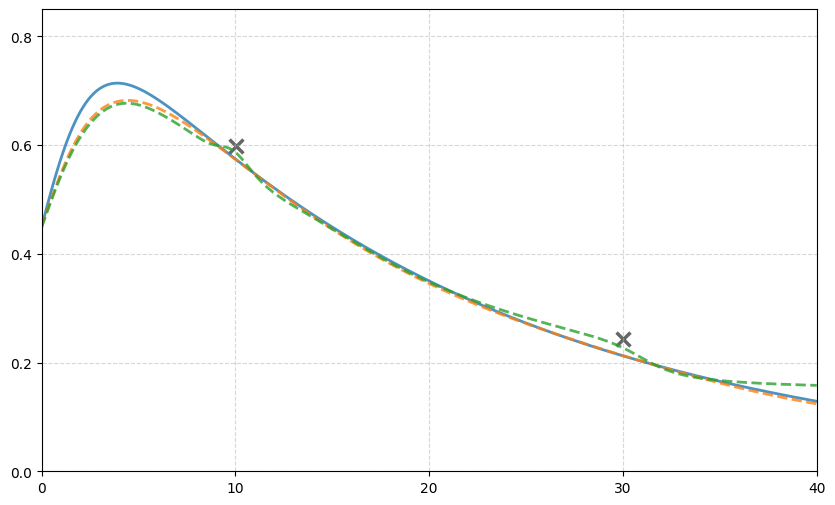

In [20]:
plt.figure(figsize = (10, 6))

# SIR
plt.scatter(tPlot[idHPointsSIR_Balanced_two], solNoisySIR[idHPointsSIR_Balanced_two, 1], label = 'Noisy data', color = black, marker = 'x', s = 100, linewidths = 2.5,  alpha = 0.6)
plt.plot(tPlot, solSIR[:, 1], color = "tab:blue", linestyle = '-', linewidth = 2.0, alpha = 0.8, label = 'I real')
plt.plot(tPlot, modelSIR_Balanced_Plot_two[:, 1], color = "tab:orange", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. balanced')
plt.plot(tPlot, modelSIR_Unbalanced_Plot_two[:, 1], color = "tab:green", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.margins(0)
plt.ylim(0.0, 0.85)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

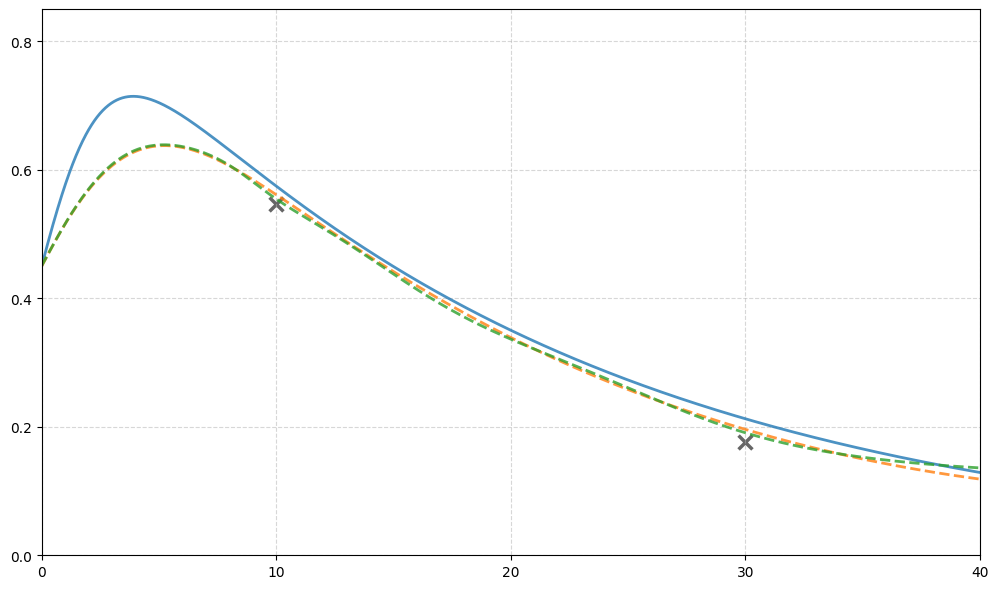

In [21]:
plt.figure(figsize = (10, 6))

# MT
plt.scatter(tPlot[idHPointsMT_Unbalanced_two], solNoisyMT[idHPointsMT_Balanced_two, 1], label = 'Noisy data', color = black, marker = 'x', s = 100, linewidths = 2.5,  alpha = 0.6)
plt.plot(tPlot, solMT[:, 1], color = "tab:blue", linestyle = '-', linewidth = 2.0, alpha = 0.8, label = 'Y real')
plt.plot(tPlot, modelMT_Balanced_Plot_two[:, 1], color = "tab:orange", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. balanced')
plt.plot(tPlot, modelMT_Unbalanced_Plot_two[:, 1], color = "tab:green", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
#plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
#plt.title("Maki-Thompson model", fontsize = 15)
plt.margins(0.0)
plt.ylim(0.0, 0.85)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

## 8 points

In [22]:
h_points_eight =  np.array([3, 8, 13, 18, 23, 28, 33, 38])

In [23]:
print("Start")
modelSIR_Balanced, idHPointsSIR_Balanced = train(h_points_eight, t_real, solNoisySIR, 50, y_0, True, lr, 0.0, 40.0, n_points, 10000, "SIR")
modelSIR_Balanced_Plot = modelSIR_Balanced(t_real).detach().numpy()

modelSIR_Unbalanced, idHPointsSIR_Unbalanced = train(h_points_eight, t_real, solNoisySIR, 50, y_0, False, lr, 0.0, 40.0, n_points, 10000, "SIR")
modelSIR_Unbalanced_Plot = modelSIR_Unbalanced(t_real).detach().numpy()

print("End")

Start
End


In [24]:
np.savez("sir_results_cache_8.npz", 
         sol_noisy = solNoisySIR,
         pred_balanced = modelSIR_Balanced_Plot,
         pred_unbalanced = modelSIR_Unbalanced_Plot,
         H_POINTS = idHPointsSIR_Balanced)

In [25]:
print("Start")
modelMT_Balanced, idHPointsMT_Balanced = train(h_points_eight, t_real, solNoisyMT, 50, y_0, True, lr, 0.0, 40.0, n_points, 10000, "MT")
modelMT_Balanced_Plot = modelMT_Balanced(t_real).detach().numpy()

modelMT_Unbalanced, idHPointsMT_Unbalanced = train(h_points_eight, t_real, solNoisyMT, 50, y_0, False, lr, 0.0, 40.0, n_points, 10000, "MT")
modelMT_Unbalanced_Plot = modelMT_Unbalanced(t_real).detach().numpy()

print("End")

Start
End


In [26]:
np.savez("MT_results_cache_8.npz", 
         sol_noisy = solNoisyMT,
         pred_balanced = modelMT_Balanced_Plot,
         pred_unbalanced = modelMT_Unbalanced_Plot,
         H_POINTS = idHPointsMT_Balanced)

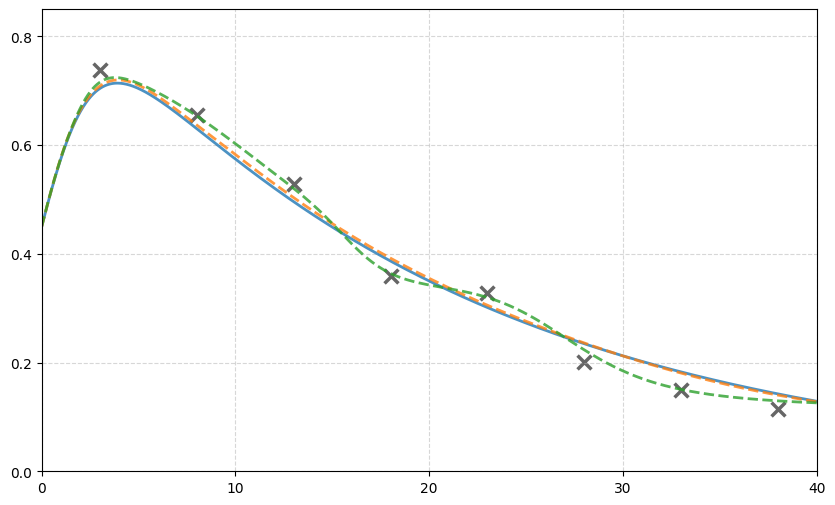

In [27]:
plt.figure(figsize = (10, 6))

# SIR
plt.scatter(tPlot[idHPointsSIR_Balanced], solNoisySIR[idHPointsSIR_Balanced, 1], label = 'Noisy data', color = black, marker = 'x', s = 100, linewidths = 2.5,  alpha = 0.6)
plt.plot(tPlot, solSIR[:, 1], color = "tab:blue", linestyle = '-', linewidth = 2.0, alpha = 0.8, label = 'I real')
plt.plot(tPlot, modelSIR_Balanced_Plot[:, 1], color = "tab:orange", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. balanced')
plt.plot(tPlot, modelSIR_Unbalanced_Plot[:, 1], color = "tab:green", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
plt.margins(0)
plt.ylim(0.0, 0.85)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

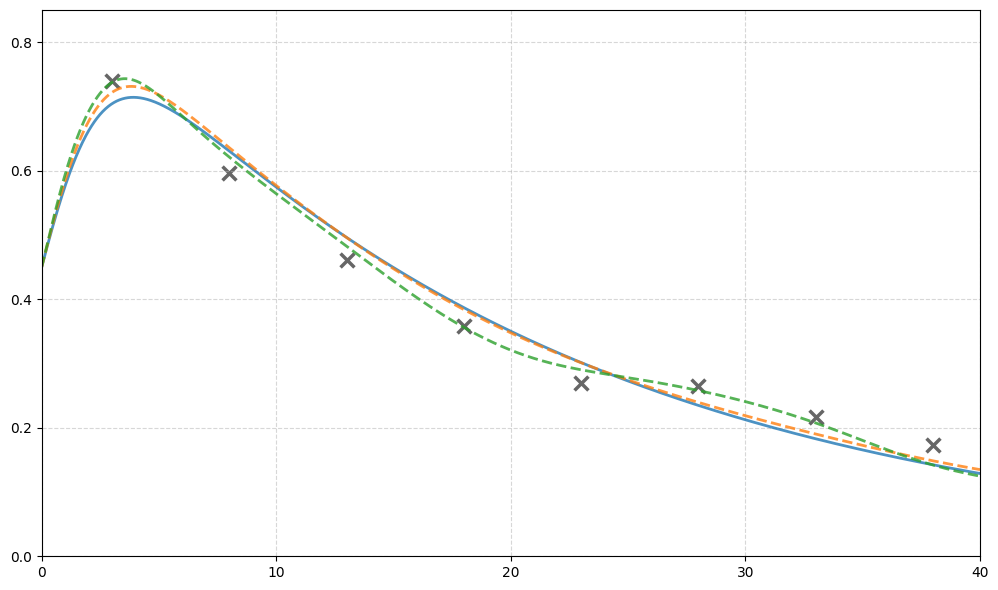

In [28]:
plt.figure(figsize = (10, 6))

# MT
plt.scatter(tPlot[idHPointsMT_Unbalanced], solNoisyMT[idHPointsMT_Unbalanced, 1], label = 'Noisy data', color = black, marker = 'x', s = 100, linewidths = 2.5,  alpha = 0.6)
plt.plot(tPlot, solMT[:, 1], color = "tab:blue", linestyle = '-', linewidth = 2.0, alpha = 0.8, label = 'Y real')
plt.plot(tPlot, modelMT_Balanced_Plot[:, 1], color = "tab:orange", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. balanced')
plt.plot(tPlot, modelMT_Unbalanced_Plot[:, 1], color = "tab:green", linestyle = '--', linewidth = 2.0, alpha = 0.8, label = 'Approx. unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
#plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
#plt.title("Maki-Thompson model", fontsize = 15)
plt.margins(0.0)
plt.ylim(0.0, 0.85)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

## Training partial information

In [12]:
def train(t_h, t_real, sol_noisy, nColloc, y_0, hasWeights, lr, tStart, tEnd, nPoints, nEpochs, modelType):
  if (modelType == "SIR"):
    model = sir_nn(t_real)
  elif(modelType == "MT"):
    model = MT_nn(t_real)
  
  # Optimizer
  optimizer = optim.Adam(model.parameters(), lr)
  
  # Weights
  ic_weight = 10.0
  edo_weight = 40.0
  data_weight = 0.9
  sum_weight = 1.0

  t_real_np = t_real.detach().numpy()
  # Helper points
  id_h_points = []
  for t_val in t_h:
    idx = np.argmin(np.abs(t_real_np - t_val))
    id_h_points.append(idx)
  
  id_h_points = np.array(id_h_points)
  solH = torch.tensor(sol_noisy[id_h_points])

  t_h = torch.tensor(t_h, dtype=torch.float32).reshape(-1, 1)
  
  # tColloc
  tColloc = torch.linspace(tStart, tEnd, nColloc).reshape(-1, 1)
  tColloc.requires_grad = True
  
  _0_0Tensor = torch.tensor([0.0])
  
  # y0 tensor
  y_0_t = torch.tensor(y_0)


  # Training loop
  for epoch in range(nEpochs):
    pred = model(tColloc)
    one, two, three = pred[:, 0:1], pred[:, 1:2], pred[:, 2:3]
    
    # Loss IC
    lossIC = torch.mean((model(_0_0Tensor) - y_0_t)**2)

    # Loss EDO
    done_dt = torch.autograd.grad(one, tColloc, grad_outputs= torch.ones_like(one), create_graph= True)[0]
    dtwo_dt = torch.autograd.grad(two, tColloc, grad_outputs= torch.ones_like(two), create_graph= True)[0]
    dthree_dt = torch.autograd.grad(three, tColloc, grad_outputs= torch.ones_like(three), create_graph= True)[0]

    if (modelType == 'SIR'):
      diff_one = done_dt + model.beta * one * two
      diff_two = dtwo_dt - model.beta * one * two + model.gamma * two
      diff_three = dthree_dt -  model.gamma * two
    elif (modelType == 'MT'):
      diff_one = done_dt + model.lambd * one * two
      diff_two = dtwo_dt - model.lambd * one * two + model.alpha * two * (1 - one)
      diff_three = dthree_dt - model.alpha * two * (1 - one)

    lossEDO = torch.mean(diff_one**2 + diff_two**2 + diff_three**2)

    # Loss Data
    tmpData = model(t_h)
    lossData = torch.mean((tmpData[:, 1] - solH[:, 1])**2)
    
    # Loss SUM_1
    lossSUM_1 = torch.mean((1.0 - one - two - three)**2)

    if (hasWeights == True):
        loss = (ic_weight * lossIC + edo_weight * lossEDO + data_weight * lossData + sum_weight * lossSUM_1)
    else:
        loss = lossIC + lossEDO + lossData + lossSUM_1

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  return model, id_h_points

In [21]:
outliersNoisePerc = 30.0
outliersPerc = 25.0 
nPoints = 16

#h_points_sixteen = np.array([2, 4, 7, 9, 11, 14, 16, 19, 21, 24, 26, 29, 31, 34, 36, 38])
h_points_sixteen = np.array([2, 7, 9, 11, 16, 19, 21, 24, 29, 31, 34, 38])

t_real_np = t_real.detach().numpy()
# Helper points
id_h_points = []
for t_val in h_points_sixteen:
  idx = np.argmin(np.abs(t_real_np - t_val))
  id_h_points.append(idx)


id_h_points = np.array(id_h_points)
print(id_h_points)

[ 100  350  450  550  800  950 1049 1199 1449 1549 1699 1899]


In [22]:
selectedOutliers = np.array([350, 1049, 1549, 1699])
print(selectedOutliers)

[ 350 1049 1549 1699]


In [23]:
print("Start")
noiseBaseSIR, noiseSignSIR = getNoiseBase(solSIR)
solNoisySIR = getNoisySolution(solSIR, noiseBaseSIR, noiseSignSIR, 5.0)

nOutliers = int(nPoints * outliersPerc/ 100.0)
#selectedOutliers = np.random.choice(id_h_points, nOutliers, replace = False)
#selectedOutliers = np.array([350, 1049, 1549, 1699])
outliersNoiseData = getNoisySolution(solSIR, noiseBaseSIR, noiseSignSIR, outliersNoisePerc)
solNoisySIR[selectedOutliers] = outliersNoiseData[selectedOutliers]


modelSIR_Balanced, idHPointsSIR_Balanced = train(h_points_sixteen, t_real, solNoisySIR, 50, y_0, True, lr, 0.0, 40.0, n_points, 10000, "SIR")
modelSIR_Balanced_Plot = modelSIR_Balanced(t_real).detach().numpy()

modelSIR_Unbalanced, idHPointsSIR_Unbalanced = train(h_points_sixteen, t_real, solNoisySIR, 50, y_0, False, lr, 0.0, 40.0, n_points, 10000, "SIR")
modelSIR_Unbalanced_Plot = modelSIR_Unbalanced(t_real).detach().numpy()

print("End")

Start
End


In [24]:
np.savez("SIR_partial_12.npz", 
         sol_noisy = solNoisySIR,
         pred_balanced = modelSIR_Balanced_Plot,
         pred_unbalanced = modelSIR_Unbalanced_Plot,
         H_POINTS = idHPointsSIR_Balanced)

In [25]:
print("Start")
noiseBaseMT, noiseSignMT = getNoiseBase(solMT)
solNoisyMT = getNoisySolution(solMT, noiseBaseSIR, noiseSignSIR, 5.0)

nOutliers = int(nPoints * outliersPerc/ 100.0)
#selectedOutliers = np.random.choice(id_h_points, nOutliers, replace = False)
outliersNoiseData = getNoisySolution(solMT, noiseBaseSIR, noiseSignSIR, outliersNoisePerc)
solNoisyMT[selectedOutliers] = outliersNoiseData[selectedOutliers]

modelMT_Balanced, idHPointsMT_Balanced = train(h_points_sixteen, t_real, solNoisySIR, 50, y_0, True, lr, 0.0, 40.0, n_points, 10000, "MT")
modelMT_Balanced_Plot = modelMT_Balanced(t_real).detach().numpy()

modelMT_Unbalanced, idHPointsMT_Unbalanced = train(h_points_sixteen, t_real, solNoisySIR, 50, y_0, False, lr, 0.0, 40.0, n_points, 10000, "MT")
modelMT_Unbalanced_Plot = modelMT_Unbalanced(t_real).detach().numpy()

print("End")

Start
End


In [26]:
np.savez("MT_partial_12.npz", 
         sol_noisy = solNoisyMT,
         pred_balanced = modelMT_Balanced_Plot,
         pred_unbalanced = modelMT_Unbalanced_Plot,
         H_POINTS = idHPointsMT_Balanced)

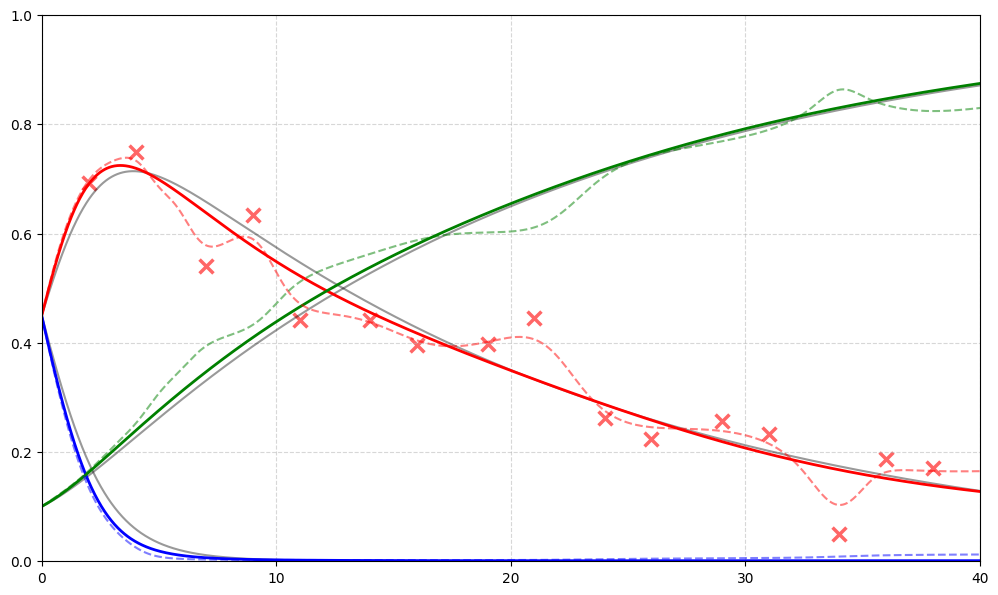

In [40]:
plt.figure(figsize = (10, 6))

# SIR
plt.scatter(tPlot[idHPointsSIR_Balanced], solNoisySIR[idHPointsSIR_Balanced, 1], label = 'Noisy data', color = 'red', marker = 'x',  s = 100, linewidths = 2.5,  alpha = 0.6)

plt.plot(tPlot, solSIR[:, 0], color = 'black', linestyle = '-', linewidth = 1.5, alpha = 0.4, label = 'S/I/R real')
plt.plot(tPlot, solSIR[:, 1], color = 'black', linestyle = '-', linewidth = 1.5, alpha = 0.4)
plt.plot(tPlot, solSIR[:, 2], color = 'black', linestyle = '-', linewidth = 1.5, alpha = 0.4)

plt.plot(tPlot, modelSIR_Balanced_Plot[:, 0], color = 'blue', linestyle = '-', linewidth = 2, alpha = 1.0, label = 'Approx. S balanced')
plt.plot(tPlot, modelSIR_Balanced_Plot[:, 1], color = 'red', linestyle = '-', linewidth = 2, alpha = 1.0, label = 'Approx. I balanced')
plt.plot(tPlot, modelSIR_Balanced_Plot[:, 2], color = 'green', linestyle = '-', linewidth = 2, alpha = 1.0, label = 'Approx. R balanced')

plt.plot(tPlot, modelSIR_Unbalanced_Plot[:, 0], color = 'blue', linestyle = '--', linewidth = 1.5, alpha = 0.5, label = 'Approx. S unbalanced')
plt.plot(tPlot, modelSIR_Unbalanced_Plot[:, 1], color = 'red', linestyle = '--', linewidth = 1.5, alpha = 0.5, label = 'Approx. I unbalanced')
plt.plot(tPlot, modelSIR_Unbalanced_Plot[:, 2], color = 'green', linestyle = '--', linewidth = 1.5, alpha = 0.5, label = 'Approx. R unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
#plt.xlabel('Time (t)', fontsize=12)
#plt.ylabel('Population fraction', fontsize=12)
#plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
#plt.title("SIR model", fontsize = 15)
plt.margins(0.0)
plt.ylim(0.0, 1.0)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()

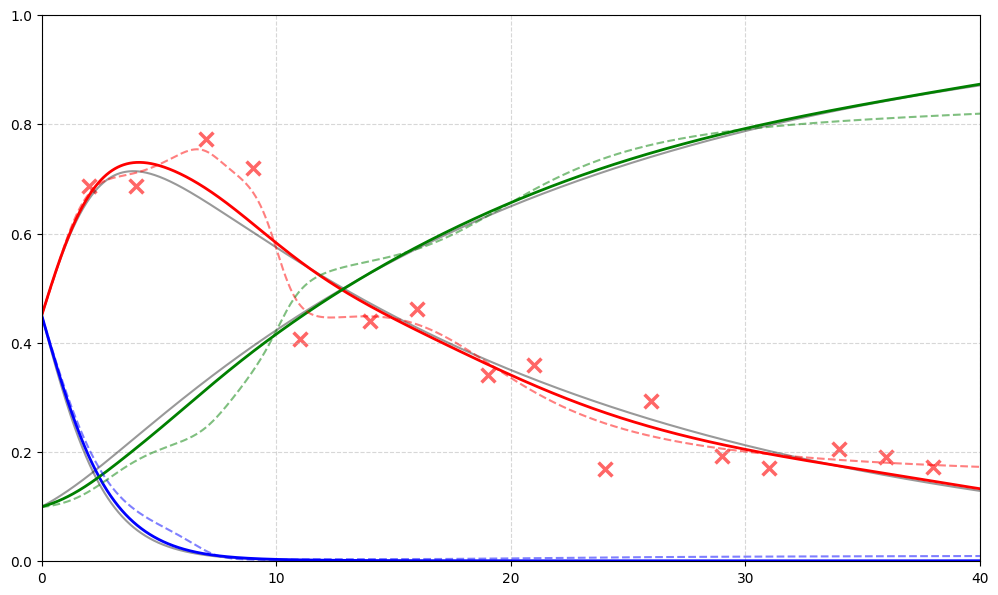

In [47]:
plt.figure(figsize = (10, 6))

# MT
plt.scatter(tPlot[idHPointsMT_Balanced], solNoisyMT[idHPointsMT_Balanced, 1], label = 'Noisy data', color = 'red', marker = 'x', s = 100, linewidths = 2.5, alpha = 0.6)

plt.plot(tPlot, solMT[:, 0], color = 'black', linestyle = '-', linewidth = 1.5, alpha = 0.4, label = 'X/Y/Z real')
plt.plot(tPlot, solMT[:, 1], color = 'black', linestyle = '-', linewidth = 1.5, alpha = 0.4)
plt.plot(tPlot, solMT[:, 2], color = 'black', linestyle = '-', linewidth = 1.5, alpha = 0.4)

plt.plot(tPlot, modelMT_Balanced_Plot[:, 0], color = 'blue', linestyle = '-', linewidth = 2, alpha = 1.0, label = 'Approx. X balanced')
plt.plot(tPlot, modelMT_Balanced_Plot[:, 1], color = 'red', linestyle = '-', linewidth = 2, alpha = 1.0, label = 'Approx. Y balanced')
plt.plot(tPlot, modelMT_Balanced_Plot[:, 2], color = 'green', linestyle = '-', linewidth = 2, alpha = 1.0, label = 'Approx. Z balanced')

plt.plot(tPlot, modelMT_Unbalanced_Plot[:, 0], color = 'blue', linestyle = '--', linewidth = 1.5, alpha = 0.5, label = 'Approx. X unbalanced')
plt.plot(tPlot, modelMT_Unbalanced_Plot[:, 1], color = 'red', linestyle = '--', linewidth = 1.5, alpha = 0.5, label = 'Approx. Y unbalanced')
plt.plot(tPlot, modelMT_Unbalanced_Plot[:, 2], color = 'green', linestyle = '--', linewidth = 1.5, alpha = 0.5, label = 'Approx. Z unbalanced')

plt.grid(True, which = 'both', linestyle='--', alpha = 0.5)
#plt.xlabel('Time (t)', fontsize=12)
#plt.ylabel('Population fraction', fontsize=12)
#plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
plt.tight_layout()
#plt.title("Maki-Thompson model", fontsize = 15)
plt.ylim(0.0, 1.0)
plt.margins(0.0)
ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(0.2))
plt.show()